In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import xarray as xr

discharge = xr.open_dataset(
    "/Users/ldr.riedel/experiments/climada-ce/data/hazard/glofas-reforecast-25-07.grib"
)
discharge

/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


<xarray.Dataset> Size: 288MB
Dimensions:     (number: 10, time: 3, step: 10, latitude: 400, longitude: 600)
Coordinates:
  * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time        (time) datetime64[ns] 24B 2021-07-06 2021-07-10 2021-07-13
  * step        (step) timedelta64[ns] 80B 1 days 2 days ... 9 days 10 days
    surface     float64 8B ...
  * latitude    (latitude) float64 3kB 59.98 59.93 59.88 ... 40.13 40.08 40.02
  * longitude   (longitude) float64 5kB -9.975 -9.925 -9.875 ... 19.93 19.98
    valid_time  (time, step) datetime64[ns] 240B ...
Data variables:
    dis24       (number, time, step, latitude, longitude) float32 288MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-06T14:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
from climada_petals.hazard.rf_glofas import RiverFloodInundation
from climada_petals.hazard.rf_glofas.rf_glofas import dask_client

rf = RiverFloodInundation()
flood_depth = rf.compute(
    discharge=discharge["dis24"],
    load_flood_maps_kws={"coarsening": 10},
    apply_protection=False,
)
flood_depth

/Users/ldr.riedel/coding/climada_petals/climada_petals/hazard/rf_glofas/river_flood_computation.py:209: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  self.gumbel_fits = xr.open_dataset(
/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/dask/array/gufunc.py:485: PerformanceWarning: Increasing number of chunks by factor of 17
  tmp = blockwise(
/Users/ldr.riedel/miniforge3/envs/climada_env_3.11/lib/python3.11/site-packages/dask/array/gufunc.py:485: Perfor

<xarray.Dataset> Size: 21GB
Dimensions:              (number: 10, time: 3, step: 10, longitude: 3594,
                          latitude: 2394)
Coordinates:
  * number               (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time                 (time) datetime64[ns] 24B 2021-07-06 ... 2021-07-13
  * step                 (step) timedelta64[ns] 80B 1 days 2 days ... 10 days
    surface              float64 8B ...
    valid_time           (time, step) datetime64[ns] 240B dask.array<chunksize=(3, 10), meta=np.ndarray>
  * longitude            (longitude) float64 29kB -9.969 -9.96 ... 19.97 19.97
  * latitude             (latitude) float64 19kB 59.97 59.97 ... 40.04 40.03
    spatial_ref          int64 8B 0
Data variables:
    flood_depth          (latitude, longitude, number, time, step) float32 10GB dask.array<chunksize=(67, 100, 10, 3, 10), meta=np.ndarray>
    flood_depth_flopros  (latitude, longitude, number, time, step) float32 10GB dask.array<chunksize=(67, 100, 10, 3, 10), meta=np.ndarray>

In [8]:
from climada_petals.hazard.rf_glofas import save_file

save_file(flood_depth, "data/hazard/glofas-reforecast-25-07.nc", zlib=True)

KeyboardInterrupt: 

In [8]:
# from climada_petals.hazard.rf_glofas import save_file
# import climadace as ce

# rf = RiverFloodInundation()
# rp_regrid = ce.open_dataset("/Users/ldr.riedel/climada/data/river-flood-computation/.cache/251003-143239-r6gdyau6/return-period-regrid.nc")
# rp_regrid = rp_regrid.set_coords("spatial_ref")
# rp_regrid = rp_regrid["Return Period"]
# ds_flood = xr.Dataset()
# ds_flood["flood_depth"] = rf.flood_depth(rp_regrid)
# rp_regrid_flopros = rf.apply_protection(rp_regrid)
# ds_flood["flood_depth_flopros"] = rf.flood_depth(rp_regrid_flopros)
# save_file(ds_flood, "data/hazard/glofas-reforecast-25-07.nc", zlib=True)

/Users/ldr.riedel/coding/climada_petals/climada_petals/hazard/rf_glofas/river_flood_computation.py:209: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  self.gumbel_fits = xr.open_dataset(


FileNotFoundError: [Errno 2] No such file or directory: '/Users/ldr.riedel/climada/data/river-flood-computation/.cache/251003-143239-r6gdyau6/return-period-regrid.nc'

In [5]:
xr.open_dataset(
    "/Users/ldr.riedel/climada/data/river-flood-computation/.cache/251003-143239-r6gdyau6/return-period-regrid.nc"
)

<xarray.Dataset> Size: 21GB
Dimensions:        (number: 10, time: 3, step: 10, latitude: 3420,
                    longitude: 5134)
Coordinates:
  * number         (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time           (time) datetime64[ns] 24B 2021-07-06 2021-07-10 2021-07-13
  * step           (step) timedelta64[ns] 80B 1 days 2 days ... 9 days 10 days
    surface        float64 8B ...
    valid_time     (time, step) datetime64[ns] 240B ...
  * longitude      (longitude) float64 41kB -9.971 -9.965 -9.959 ... 19.97 19.97
  * latitude       (latitude) float64 27kB 59.97 59.96 59.96 ... 40.03 40.03
Data variables:
    spatial_ref    int64 8B ...
    Return Period  (number, time, step, latitude, longitude) float32 21GB ...

In [ ]:
LOAD = False

In [ ]:
import numpy as np


def sigmoid(x, threshold, half_point, exponent, scale):
    luk = (x - threshold) / (half_point - threshold)
    return np.maximum(scale * luk**exponent / (1 + luk**exponent), 0.0)

In [ ]:
# impf = partial(impact_func, threshold=0.1, half_point=1.0, scale=1.0, exponent=3)
impf = lambda intensity: impact_func(
    intensity, threshold=0.1, half_point=1.0, scale=1.0, exponent=3
)

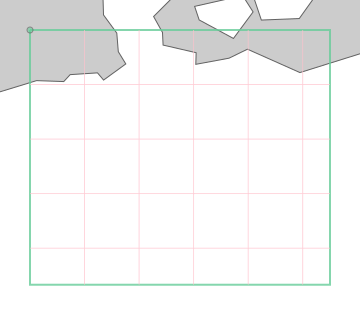

In [ ]:
import climadace as ce

exposure = ce.open_dataset(
    "data/exposure/deu_ppp_2000_1km_Aggregated_UNadj.tif",
)
exposure.odc.geobox

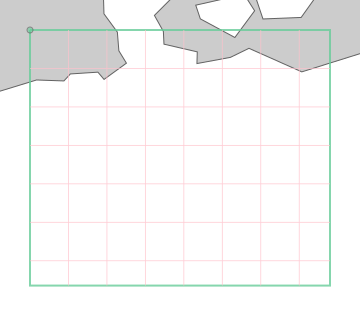

In [ ]:
hazard = ce.open_dataset("data/hazard/flood-2021-06-geo.nc")
hazard.odc.geobox

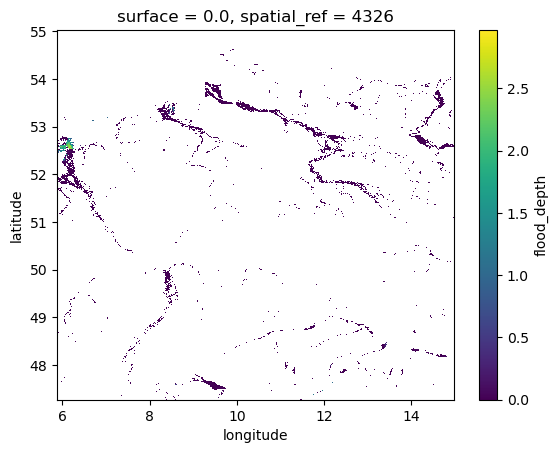

In [ ]:
hazard["flood_depth"].max(dim=["number", "time", "step"]).plot()

In [ ]:
import pandas as pd
import xarray as xr
import odc.geo.xr  # noqa: F401

import climadace as ce

# Single exposure array with time axis
exposure = xr.concat(
    [
        ce.open_dataset(
            "data/exposure/deu_ppp_2000_1km_Aggregated_UNadj.tif",
            engine="rasterio",
        ),
        ce.open_dataset(
            "data/exposure/deu_ppp_2001_1km_Aggregated_UNadj.tif",
            engine="rasterio",
        ),
    ],
    dim=pd.DatetimeIndex(["2021-06-12", "2021-06-15"], name="time"),
)
exposure = exposure.squeeze()  # band

# exposure = xr.open_dataarray(
#     "data/exposure/deu_ppp_2000_UNadj.tif",
#     chunks="auto",
#     decode_coords="all",
#     engine="rasterio",
# ).squeeze()
# exposure = (
#     exposure.sel(x=slice(5.88, 5.89), y=slice(55, 54.99)).chunk("auto")
# )
# exposure = exposure.rename({"x": "longitude", "y": "latitude"})
exposure

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 2, y: 934, x: 1100)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 16B 2021-06-12 2021-06-15
Data variables:
    band_data    (time, y, x) float32 8MB dask.array<chunksize=(1, 934, 1100), meta=np.ndarray>

In [ ]:
if LOAD:
    exposure = exposure.compute()
# exposure

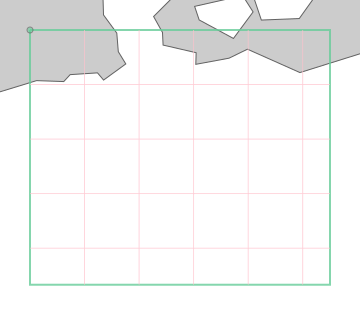

In [ ]:
exposure.odc.geobox

In [ ]:
import odc.geo.xr  # noqa: F401

hazard = xr.open_dataset(
    "data/hazard/flood-2021-06-fine.nc", chunks="auto", decode_coords="all"
)["flood_depth"]
# hazard = hazard.coarsen(longitude=2, latitude=2, boundary="trim").mean()
# hazard = hazard.isel(number=0, step=0)
hazard = hazard.odc.assign_crs("EPSG:4326")

# To dataset
hazard

/var/folders/fj/w4lbl0pd7l1gcvt664mkfnh00000gq/T/ipykernel_13864/3579539058.py:3: FutureWarning: In a future version, xarray will not decode the variable 'step' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  hazard = xr.open_dataset(


<xarray.DataArray 'flood_depth' (latitude: 1859, longitude: 2183, number: 10,
                                 time: 3, step: 5)> Size: 2GB
dask.array<open_dataset-flood_depth, shape=(1859, 2183, 10, 3, 5), dtype=float32, chunksize=(620, 728, 4, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * number       (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time         (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
  * step         (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
    surface      float64 8B ...
    valid_time   (time, step) datetime64[ns] 120B dask.array<chunksize=(3, 5), meta=np.ndarray>
  * longitude    (longitude) float64 17kB 5.878 5.883 5.887 ... 14.97 14.97
  * latitude     (latitude) float64 15kB 55.02 55.02 55.01 ... 47.29 47.28 47.28
    spatial_ref  int32 4B 4326

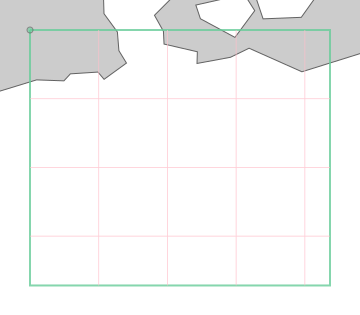

In [ ]:
hazard.odc.geobox

In [ ]:
from climadace import Aligner, Engine

align = Aligner(hazard=hazard, exposure=exposure)

In [ ]:
import cartopy
import geopandas as gpd

ne = cartopy.io.shapereader.natural_earth(
    resolution="10m", category="cultural", name="admin_0_countries"
)
ne_gdf = gpd.read_file(ne)

align.tree_split(
    ne_gdf[ne_gdf["ADM0_A3"].isin(["DEU", "CHE", "AUT", "USA"])],
    "ADM0_A3",
    dropna=True,
    # ne_gdf, "ADM0_A3", dropna=True
)

TypeError: split_from_geo() got an unexpected keyword argument 'groupby'

In [ ]:
align.get_exposure()

<xarray.DataTree>
Group: /
├── Group: /AUT
│       Dimensions:      (time: 3, y: 155, x: 172)
│       Coordinates:
│         * x            (x) float64 1kB 9.72 9.728 9.736 9.745 ... 13.8 13.81 13.82
│         * y            (y) float64 1kB 48.77 48.76 48.75 48.75 ... 47.3 47.3 47.28
│         * time         (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
│           band         int64 8B 1
│           spatial_ref  int64 8B 0
│       Data variables:
│           band_data    (time, y, x) float32 320kB dask.array<chunksize=(1, 155, 172), meta=np.ndarray>
├── Group: /CHE
│       Dimensions:      (time: 3, y: 28, x: 77)
│       Coordinates:
│         * x            (x) float64 616B 7.62 7.628 7.67 7.678 ... 9.17 9.178 9.186
│         * y            (y) float64 224B 47.8 47.8 47.79 47.78 ... 47.57 47.56 47.55
│         * time         (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
│           band         int64 8B 1
│           spatial_ref  int64 8B 0
│       Data variables:
│           band_data    (time, y, x) float32 26kB dask.array<chunksize=(1, 28, 77), meta=np.ndarray>
└── Group: /DEU
        Dimensions:      (time: 3, y: 934, x: 1098)
        Coordinates:
          * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.0 15.01 15.02
          * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
          * time         (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
            band         int64 8B 1
            spatial_ref  int64 8B 0
        Data variables:
            band_data    (time, y, x) float32 12MB dask.array<chunksize=(1, 934, 1098), meta=np.ndarray>

In [ ]:
align.get_hazard_dset()

<xarray.Dataset> Size: 616MB
Dimensions:      (number: 10, time: 3, step: 5, x: 1100, y: 934)
Coordinates:
  * number       (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time         (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
  * step         (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    surface      float64 8B ...
    valid_time   (time, step) datetime64[ns] 120B dask.array<chunksize=(1, 3), meta=np.ndarray>
    spatial_ref  int32 4B 4326
Data variables:
    band_data    (y, x, number, time, step) float32 616MB dask.array<chunksize=(934, 1100, 6, 1, 3), meta=np.ndarray>

In [ ]:
from climadace.sparse import SparseArray


def zero_to_nan(x):
    x[np.allclose(x, 0)] = np.nan
    return x


if LOAD:
    align._hazard = align._hazard.sp.to_sparse(
        array_type=SparseArray, preprocess=zero_to_nan, fill_value=np.nan
    ).compute()
# align._exposure = align._exposure.sp.to_sparse(
#     array_type=SparseArray, preprocess=zero_to_nan, fill_value=np.nan
# ).compute()
align._hazard

<xarray.Dataset> Size: 616MB
Dimensions:      (number: 10, time: 3, step: 5, x: 1100, y: 934)
Coordinates:
  * number       (number) int64 80B 1 2 3 4 5 6 7 8 9 10
  * time         (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
  * step         (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    surface      float64 8B ...
    valid_time   (time, step) datetime64[ns] 120B dask.array<chunksize=(1, 3), meta=np.ndarray>
    spatial_ref  int32 4B 4326
Data variables:
    band_data    (y, x, number, time, step) float32 616MB dask.array<chunksize=(934, 1100, 6, 1, 3), meta=np.ndarray>

In [ ]:
from climadace import FuncDefault, CachePolicy
from dask.distributed import Client

with Client(n_workers=1, threads_per_worker=2, memory_limit="4GB"):
    engine = Engine.from_aligner_no_tree(
        align, impf_map={FuncDefault: impf}, cache_policy=CachePolicy.never
    )

In [ ]:
from dask.distributed import Client

with Client(n_workers=1, threads_per_worker=2, memory_limit="4GB"):
    impact = engine.impact()
impact

<xarray.DataTree>
Group: /
├── Group: /AUT
│       Dimensions:     (number: 10, time: 3, step: 5, x: 172, y: 155)
│       Coordinates:
│         * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
│         * time        (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
│         * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
│         * x           (x) float64 1kB 9.72 9.728 9.736 9.745 ... 13.8 13.81 13.82
│         * y           (y) float64 1kB 48.77 48.76 48.75 48.75 ... 47.3 47.3 47.28
│           surface     float64 8B 0.0
│           valid_time  (time, step) datetime64[ns] 120B dask.array<chunksize=(1, 3), meta=np.ndarray>
│           band        int64 8B 1
│       Data variables:
│           band_data   (y, x, number, time, step) float32 16MB dask.array<chunksize=(155, 172, 6, 1, 3), meta=np.ndarray>
├── Group: /CHE
│       Dimensions:     (number: 10, time: 3, step: 5, x: 77, y: 28)
│       Coordinates:
│         * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
│         * time        (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
│         * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
│         * x           (x) float64 616B 7.62 7.628 7.67 7.678 ... 9.17 9.178 9.186
│         * y           (y) float64 224B 47.8 47.8 47.79 47.78 ... 47.57 47.56 47.55
│           surface     float64 8B 0.0
│           valid_time  (time, step) datetime64[ns] 120B dask.array<chunksize=(1, 3), meta=np.ndarray>
│           band        int64 8B 1
│       Data variables:
│           band_data   (y, x, number, time, step) float32 1MB dask.array<chunksize=(28, 77, 6, 1, 3), meta=np.ndarray>
└── Group: /DEU
        Dimensions:     (number: 10, time: 3, step: 5, x: 1098, y: 934)
        Coordinates:
          * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
          * time        (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
          * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
          * x           (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.0 15.01 15.02
          * y           (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
            surface     float64 8B 0.0
            valid_time  (time, step) datetime64[ns] 120B dask.array<chunksize=(1, 3), meta=np.ndarray>
            band        int64 8B 1
        Data variables:
            band_data   (y, x, number, time, step) float32 615MB dask.array<chunksize=(934, 1098, 6, 1, 3), meta=np.ndarray>

In [ ]:
from climadace.aggregates import at_event

with Client(n_workers=1, threads_per_worker=2, memory_limit="4GB"):
    data = xr.DataTree.from_dict(
        {node.path: at_event(node.ds) for node in impact.leaves}
    ).compute()

In [ ]:
data

<xarray.DataTree>
Group: /
├── Group: /AUT
│       Dimensions:     (number: 10, time: 3, step: 5)
│       Coordinates:
│         * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
│         * time        (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
│         * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
│           surface     float64 8B 0.0
│           valid_time  (time, step) datetime64[ns] 120B 2021-06-13 ... 2021-06-20
│           band        int64 8B 1
│       Data variables:
│           band_data   (number, time, step) float32 600B 0.0 0.0002699 ... 9.849 8.067
├── Group: /CHE
│       Dimensions:     (number: 10, time: 3, step: 5)
│       Coordinates:
│         * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
│         * time        (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
│         * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
│           surface     float64 8B 0.0
│           valid_time  (time, step) datetime64[ns] 120B 2021-06-13 ... 2021-06-20
│           band        int64 8B 1
│       Data variables:
│           band_data   (number, time, step) float32 600B 0.0 0.0 0.0 ... 0.0 0.0 0.0
└── Group: /DEU
        Dimensions:     (number: 10, time: 3, step: 5)
        Coordinates:
          * number      (number) int64 80B 1 2 3 4 5 6 7 8 9 10
          * time        (time) datetime64[ns] 24B 2021-06-12 2021-06-13 2021-06-15
          * step        (step) timedelta64[ns] 40B 1 days 2 days 3 days 4 days 5 days
            surface     float64 8B 0.0
            valid_time  (time, step) datetime64[ns] 120B 2021-06-13 ... 2021-06-20
            band        int64 8B 1
        Data variables:
            band_data   (number, time, step) float32 600B 0.5791 2.092 ... 1.945e+03

In [ ]:
from climadace.io import write_zarr

write_zarr(data, "data/output/at_event.zarr")